# ECMWF Open Data: Cloud Endpoints (AWS · Azure · GCS)


**Purpose.** In Notebook 01 you worked from `data.ecmwf.int`. Here we repeat the "browse → choose → download → explore → plot" flow directly on the **cloud mirrors** that host Open Data:

- **AWS S3**: public bucket `ecmwf-forecasts`
- **Azure**: via Microsoft Planetary Computer (STAC API + signed links)
- **Google Cloud Storage**: public bucket `ecmwf-open-data`

**Why this matters**
- Work **where the data lives** to reduce latency/egress.
- Use **metadata search (STAC)** on Azure to discover items without manual path spelunking.
- Keep transfers tiny with **single-parameter byte-range slicing** (via `.index`, demonstrated on AWS).

**Outcome.** You'll list a real run, preview size with HTTP `HEAD`, then:
- **On AWS:** download **only one parameter** (e.g., `2t`) using the `.index` + HTTP Range,  
- **On Azure/GCS:** fetch the equivalent object directly,  
and open/plot with Earthkit: all saved into the same project-wide `./data` cache used in Notebook 01.

> We use the **same date and run** across AWS, Azure, and GCS (computed safely below) so results are directly comparable.

### Recap: where the data lives

- **HTTP (official index):** `https://data.ecmwf.int/forecasts/...`
- **AWS S3:** `s3://ecmwf-forecasts/...` (paired `.index` for slicing)
- **Azure (Planetary Computer):** STAC `ecmwf-forecast` + signed asset URLs
- **Google Cloud:** `gs://ecmwf-open-data/...`

This notebook shows **the same file** (or nearest equivalent) via each cloud and how to:
- Discover a valid run/step,
- Fetch a small **single-parameter slice** (AWS) or download the object (Azure/GCS),
- Plot a quick map consistently across sources.

> **Status note (July 2026):** Written against the ECMWF Open Data catalogue as of mid-2026 (IFS cycle 50r1, 0.25 degree grid). An update to the Free and Open Data offering, including a move to 0.1 degree resolution, is expected later in 2026: file naming and catalogue examples here may need revisiting after that release.


## 1) Setup & shared cache

We reuse the **`./data`** cache so files remain visible across notebooks. We also print Earthkit versions for reproducibility.

> If you rebuilt your environment, ensure `s3fs`, `gcsfs`, `pystac-client`, and `planetary-computer` are installed (they are included in this project's `env/environment.yml`).

In [1]:
from pathlib import Path
import re, json, requests
from datetime import datetime, timedelta, timezone

# Cloud FS libs
import s3fs, gcsfs

# Earthkit
import earthkit.data as ekd
import earthkit.plots as ekp

# Azure STAC + signing
from pystac_client import Client as STACClient
import planetary_computer as pc

# Project helpers
from _utils import get_data_dir, quick_plot

DATA_DIR = str(get_data_dir())
print("Data cache:", DATA_DIR)
print("earthkit-data:", ekd.__version__)
print("earthkit-plots:", getattr(ekp, "__version__", "unknown"))

def _human(n):
    for unit in ("B","KB","MB","GB","TB"):
        if n < 1024 or unit == "TB":
            return f"{n:.1f} {unit}"
        n /= 1024

def _head(url, timeout=20):
    try:
        h = requests.head(url, allow_redirects=True, timeout=timeout)
        h.raise_for_status()
        size = int(h.headers.get("Content-Length", 0) or 0)
        lm = h.headers.get("Last-Modified","") or ""
        return size, lm, None
    except Exception as e:
        return 0, "", e

/Users/valtze/miniforge3/envs/ecmwf-open-data-guide/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)
/Users/valtze/miniforge3/envs/ecmwf-open-data-guide/lib/python3.10/site-packages/google/api_core/_python_version_support.py:273: FutureWarning: You are using a Python version (3.10.20) which Google will stop supporting in new releases of google.cloud.storage_control_v2 once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.cloud.storage_control_v2 past that date.
  warnings.warn(message, FutureWarning)


Data cache: /Users/valtze/ecmwf-open-data-guide/data
earthkit-data: 0.19.4
earthkit-plots: 0.6.1


## 2) Pick a **safe** model run for data download

Open Data hosted on FTP is a rolling-buffer type, while archive data from commercial providers can be more extensive, please explore the appropriate documentation for more details. We will maintain focus on recent data, and to avoid chasing files that aren't public yet, we pick a **conservative** UTC run:

- If now ≥ **22 UTC** → use **today 12z** (≥10 h elapsed)
- Else if now ≥ **10 UTC** → use **today 00z**
- Else → use **yesterday 12z**

We'll use this **same** `date` + `run` for **AWS**, **Azure**, and **GCS**.

In [2]:
# Safe, conservative run selection
now = datetime.now(timezone.utc)
if now.hour >= 22:
    run_date = now;             run_hour = 12   # today's 12z
elif now.hour >= 10:
    run_date = now;             run_hour = 0    # today's 00z
else:
    run_date = now - timedelta(days=1); run_hour = 12  # yesterday's 12z

fc_date = run_date.strftime("%Y%m%d")  # e.g. 20250903
fc_time = f"{run_hour:02}"             # "00" or "12"
print(f"Using model run: {fc_date} at {fc_time}z")

Using model run: 20260723 at 00z


## 3) AWS S3: list → pick → preview → slice & plot

**Bucket**: `ecmwf-forecasts`   
**Flow**
1. **List** the chosen date/run prefix.
2. **Pick** one `.grib2` (prefer `ifs/0p25/oper`, smallest step if present).
3. **Preview** size with HTTP `HEAD`.
4. **Read the paired `.index`**, find `_offset`/`_length` for a parameter (default `2t`).
5. **Download only that parameter** via HTTP **Range** (tiny transfer).  
6. **Open & plot** with Earthkit.

**About `.index` files.** They are JSON‑lines inventories for the GRIB, listing each message and its byte `_offset` and `_length`. We use them to fetch subsets of the message, notably decreasing the size and retrieval speed.

In our first cell we handle any certificate and connectivity checks, before proceeding to retrieve data.

In [3]:
# --- Preflight: S3 connectivity & CA sanity ---
import os, sys, requests

print("Python:", sys.version.split()[0])
try:
    import certifi
    CA_BUNDLE = certifi.where()
    print("certifi:", CA_BUNDLE)
except Exception:
    # macOS default; on Debian/Ubuntu use: "/etc/ssl/certs/ca-certificates.crt"
    CA_BUNDLE = "/etc/ssl/cert.pem"
    print("certifi not found; using:", CA_BUNDLE)

# Show proxy/CA environment if present (requests uses these automatically)
for v in ("HTTPS_PROXY","HTTP_PROXY","NO_PROXY","REQUESTS_CA_BUNDLE","SSL_CERT_FILE"):
    if os.environ.get(v):
        print(f"{v} =", os.environ[v])

# Quick S3 ListObjectsV2 probe (0 keys) for your region/bucket
_BUCKET = "ecmwf-forecasts"
_REGION = "eu-central-1"
TEST_URL = f"https://{_BUCKET}.s3.{_REGION}.amazonaws.com/?list-type=2&max-keys=0"

try:
    r = requests.get(TEST_URL, timeout=10, verify=CA_BUNDLE)
    r.raise_for_status()
    print("S3 preflight: OK")
except requests.exceptions.SSLError as e:
    print("\nTLS/CA problem. If your org does TLS interception, set:")
    print("  export REQUESTS_CA_BUNDLE=/path/to/corporate-root.pem")
    print("  export SSL_CERT_FILE=$REQUESTS_CA_BUNDLE")
    raise
except Exception as e:
    print("\nNetwork/proxy problem reaching S3. If behind proxy, set HTTPS_PROXY/HTTP_PROXY.")
    raise

# Make CA_BUNDLE visible to later cells
globals()["CA_BUNDLE"] = CA_BUNDLE

Python: 3.10.20
certifi: /Users/valtze/miniforge3/envs/ecmwf-open-data-guide/lib/python3.10/site-packages/certifi/cacert.pem
S3 preflight: OK


Now we access the data storage and retrieve a file. We use several small functions here find and download an existing file.

In [4]:
# --- AWS: List & choose a GRIB with one-run-back fallback (no s3fs) ---
import re, math, datetime as dt, requests, urllib.parse as _u
import xml.etree.ElementTree as ET

# Require CA bundle from the preflight cell
try:
    CA_BUNDLE
except NameError:
    try:
        import certifi
        CA_BUNDLE = certifi.where()
    except Exception:
        CA_BUNDLE = "/etc/ssl/cert.pem"  # macOS default; Debian/Ubuntu: /etc/ssl/certs/ca-certificates.crt

# Ensure we have a starting date/run (prefer your earlier "safe" vars)
if "fc_date" not in globals() or "fc_time" not in globals():
    # fallback: try widget globals from Notebook 01 if they exist
    if "date_str" in globals() and "run_str" in globals():
        fc_date, fc_time = date_str, run_str
    else:
        raise ValueError("fc_date/fc_time not defined. Run the 'safe date/run' cell first.")

bucket = "ecmwf-forecasts"
region = "eu-central-1"
RUNS = ["00", "06", "12", "18"]

def _prev_run(date_str: str, run_str: str):
    """One step back in the run cycle (00 -> previous day 18)."""
    i = RUNS.index(run_str)
    if i > 0:
        return date_str, RUNS[i-1]
    d = dt.datetime.strptime(date_str, "%Y%m%d") - dt.timedelta(days=1)
    return d.strftime("%Y%m%d"), "18"

def _list_public_s3(bucket: str, region: str, prefix: str, ca):
    """Unsigned ListObjectsV2 over HTTPS, returns list of 'Key' strings."""
    base = f"https://{bucket}.s3.{region}.amazonaws.com/"
    params = {"list-type": "2", "prefix": prefix, "max-keys": "1000"}
    keys, token = [], None
    while True:
        if token:
            params["continuation-token"] = token
        url = base + "?" + _u.urlencode(params, safe="/")
        r = requests.get(url, timeout=30, verify=ca)
        r.raise_for_status()
        root = ET.fromstring(r.text)
        ns = {"s3": "http://s3.amazonaws.com/doc/2006-03-01/"}
        keys.extend([
            c.findtext("s3:Key", default="", namespaces=ns)
            for c in root.findall("s3:Contents", ns)
        ])
        if root.findtext("s3:IsTruncated", default="false", namespaces=ns).lower() != "true":
            break
        token = root.findtext("s3:NextContinuationToken", default=None, namespaces=ns)
        if not token:
            break
    return keys

def _step_from_name(name: str) -> int:
    m = re.search(r"-(\d+)h-", name)
    return int(m.group(1)) if m else math.inf

def _pick_best(keys):
    """Prefer IFS/0p25/oper; sort by smallest step; fallback to any .grib2."""
    gribs = [k for k in keys if k.endswith(".grib2")]
    pref  = [k for k in gribs if "/ifs/" in k and "/0p25/" in k and "/oper/" in k]
    ordered = sorted(pref or gribs, key=lambda k: (_step_from_name(k), k))
    return ordered[0] if ordered else None

# Try current run, then step back up to 6 times
attempts = []
date_try, run_try = fc_date, fc_time
key = None
for _ in range(6):
    prefix = f"{date_try}/{run_try}z/"
    try:
        keys = _list_public_s3(bucket, region, prefix, CA_BUNDLE)
    except requests.exceptions.SSLError:
        raise RuntimeError("TLS/CA problem during S3 listing. See preflight cell for CA/proxy setup.")
    key = _pick_best(keys)
    attempts.append((date_try, run_try, bool(key)))
    if key:
        break
    date_try, run_try = _prev_run(date_try, run_try)

if not key:
    msg = "No .grib2 found under these runs:\n" + "\n".join(
        f"- {d} {r}z: {'OK' if ok else 'EMPTY'}" for d, r, ok in attempts
    )
    raise RuntimeError(msg + "\nTry again later or pick another model/date/run.")

# Region-correct HTTPS object URL
http_url = f"https://{bucket}.s3.{region}.amazonaws.com/{key}"

# Small HEAD probe (size + last-modified)
def _head_info(url, ca):
    try:
        h = requests.head(url, allow_redirects=True, timeout=15, verify=ca)
        size = int(h.headers.get("Content-Length", "0"))
        lm = h.headers.get("Last-Modified", "")
        return size, lm
    except Exception:
        return 0, ""

def _human(n):
    return f"{n/1e9:.2f} GB" if n >= 1e9 else f"{n/1e6:.1f} MB"

size, lm = _head_info(http_url, CA_BUNDLE)
print(f"Chosen: s3://{bucket}/{key}")
print(f"Preview: {_human(size) if size else 'unknown'} | Last-Modified: {lm or 'n/a'}")

# Expose for downstream cells
globals().update({
    "aws_bucket": bucket,
    "aws_region": region,
    "aws_date": date_try,
    "aws_run": run_try,
    "key": key,
    "http_url": http_url,
})

Chosen: s3://ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-0h-oper-fc.grib2
Preview: 134.8 MB | Last-Modified: Thu, 23 Jul 2026 07:34:01 GMT


Finally we explore how to retrieve only a subset of the file (message). In this example we slice the file and retrieve only the 2t parameter from the file.

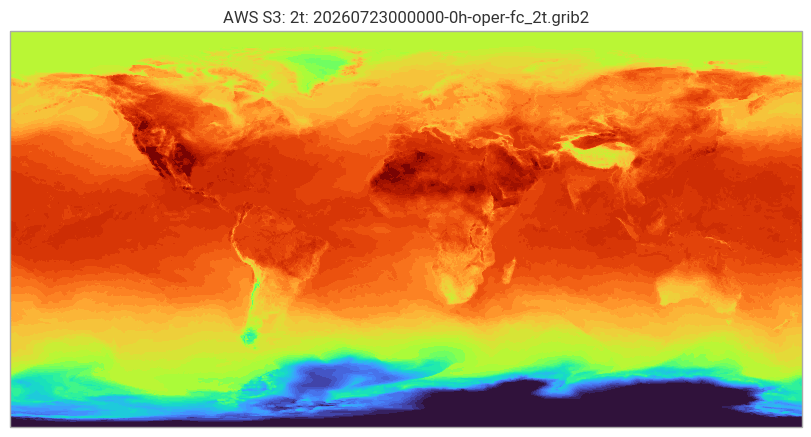

In [5]:
# --- AWS: Single-parameter slice via .index + HTTP Range (no s3fs) ---
import json
from pathlib import Path
import requests

# Parameter shortName to extract (e.g., "2t", "msl", "tp", "10u", "10v")
PARAM_AWS = "2t"

# Require URL from previous cell
if "http_url" not in globals() or "key" not in globals():
    raise RuntimeError("No selected object. Run the AWS list/choose cell first.")

# CA bundle from preflight (fallback if missing)
try:
    CA_BUNDLE
except NameError:
    try:
        import certifi
        CA_BUNDLE = certifi.where()
    except Exception:
        CA_BUNDLE = "/etc/ssl/cert.pem"

# Download & parse the JSONL index sitting next to the GRIB
idx_url = http_url.replace(".grib2", ".index")
r = requests.get(idx_url, timeout=30, verify=CA_BUNDLE)
r.raise_for_status()

offset = length = None
for line in r.text.splitlines():
    try:
        obj = json.loads(line)
    except Exception:
        continue
    sn = (obj.get("shortName") or "").lower()
    pn = str(obj.get("param") or "")
    if sn == PARAM_AWS.lower() or pn == PARAM_AWS:
        offset = int(obj["_offset"])
        length = int(obj["_length"])
        break

if offset is None:
    raise RuntimeError(f"{PARAM_AWS!r} not found in index: {idx_url}")

start, end = offset, offset + length - 1

# Save into the shared data cache
try:
    DATA_DIR  # defined earlier?
except NameError:
    from _utils import get_data_dir
    DATA_DIR = get_data_dir()

slice_name = Path(key).name.replace(".grib2", f"_{PARAM_AWS}.grib2")
slice_path = Path(DATA_DIR) / slice_name
slice_path.parent.mkdir(parents=True, exist_ok=True)

print(f"Downloading slice {PARAM_AWS}: bytes {start}-{end} → {slice_path}")
with requests.get(
    http_url,
    headers={"Range": f"bytes={start}-{end}"},
    stream=True,
    timeout=(10, 600),
    verify=CA_BUNDLE,
) as rr:
    rr.raise_for_status()
    with open(slice_path, "wb") as out:
        for chunk in rr.iter_content(256 * 1024):
            if chunk:
                out.write(chunk)

# Open & quick-plot with Earthkit
try:
    ekd  # earthkit.data
except NameError:
    import earthkit.data as ekd

try:
    quick_plot  # your helper
except NameError:
    # minimal fallback if your quick_plot isn't defined
    import earthkit.plots as ekp
    def quick_plot(field, title=None):
        ax = ekp.quickplot(field)
        try:
            import matplotlib.pyplot as plt
            if title:
                plt.title(title)
        except Exception:
            pass
        return ax

ds = ekd.from_source("file", str(slice_path))
fld = ds[0]
_ = quick_plot(fld, title=f"AWS S3: {PARAM_AWS}: {slice_path.name}")


## 4) Azure (Microsoft Planetary Computer): STAC search → signed URL → slice & plot

On Azure we don't guess paths: we **search** the **`ecmwf-forecast`** collection via **STAC**, and **sign** the asset URLs:

**Flow**
1. Search STAC for items; pick one that matches our **safe date/run** and prefer shorter steps (0/3/6 h).
2. Sign both the **GRIB** and the paired **`.index`** with `planetary_computer`.
3. Parse the `.index`, compute the byte range for the parameter.
4. Fetch just those bytes via HTTP **Range**.
5. Plot the small slice with Earthkit.

> If the first item is slow or long (e.g., 360 h), we will try another item from the search iterator. We use the previously set fc_date and fc_time variables to look for recent data.


In [6]:
# --- Azure: STAC search & robust pick for our fc_date/fc_time (prefer IFS data: oper-fc) ---
from pystac_client import Client as STACClient
import planetary_computer as pc
import requests, re, json
from pathlib import Path

COL_ID = "ecmwf-forecast"
cat = STACClient.open("https://planetarycomputer.microsoft.com/api/stac/v1")

yyyy, mm, dd = fc_date[:4], fc_date[4:6], fc_date[6:8]
date_tag = f"{yyyy}-{mm}-{dd}"   # e.g. 2025-09-07
time_tag = f"T{fc_time}"         # "T00" or "T12"

def _step_from_href(href: str) -> int:
    m = re.search(r"-([0-9]+)h-", href)
    return int(m.group(1)) if m else 9999

def _grib_assets(item):
    # Assets are sometimes keyed "data" or "grib": just take any .grib2
    return [a.href for a in item.assets.values() if a.href.endswith(".grib2")]

def _search_items(query=None, max_items=200):
    return list(cat.search(
        collections=[COL_ID],
        query=query or {},
        sortby=[{"field":"properties.datetime","direction":"desc"}],
        max_items=max_items
    ).items())

def pick_azure_asset_robust():
    # 1) Exact run, atmospheric deterministic (oper-fc)
    q1 = {"ecmwf:stream": {"eq": "oper"}, "ecmwf:type": {"eq": "fc"}}
    items = _search_items(q1, 200)
    exact = [(it, href) for it in items if (date_tag in it.id and time_tag in it.id)
             for href in _grib_assets(it)]
    if exact:
        exact.sort(key=lambda p: _step_from_href(p[1]))
        return exact[0], False  # (item, href), no fallback

    # 2) Same date (any run), atmos oper-fc, shortest step
    same_date = [(it, href) for it in items if (date_tag in it.id)
                 for href in _grib_assets(it)]
    if same_date:
        same_date.sort(key=lambda p: _step_from_href(p[1]))
        return same_date[0], True

    # 3) Latest atmos oper-fc (shortest step)
    if not items:
        items = _search_items(q1, 120)
    cand = [(it, href) for it in items for href in _grib_assets(it)]
    if cand:
        cand.sort(key=lambda p: _step_from_href(p[1]))
        return cand[0], True

    # 4) Latest non-wave (shortest step) as a last resort
    items_any = _search_items({}, 60)
    cand = [(it, href) for it in items_any if "wave" not in it.id.lower()
            for href in _grib_assets(it)]
    if cand:
        cand.sort(key=lambda p: _step_from_href(p[1]))
        return cand[0], True

    return None, True

picked, used_fallback = pick_azure_asset_robust()
if not picked:
    raise RuntimeError("Azure: no suitable item found even after fallback.")
item, href = picked

# Sign GRIB + index
signed_grib = pc.sign(href)
signed_idx  = pc.sign(href.replace(".grib2", ".index"))

# Print what we matched
props = getattr(item, "properties", {})
stream = props.get("ecmwf:stream", "unknown")
ftype  = props.get("ecmwf:type", "unknown")
step   = props.get("ecmwf:step", "unknown")
print("Azure item:", item.id)
print(f"Stream={stream}, Type={ftype}, Step={step}")
print("Selected asset:", Path(href).name)
size = int(requests.head(signed_grib, allow_redirects=True, timeout=20).headers.get("Content-Length", 0) or 0)
print("Preview size:", f"{size/1e6:.1f} MB")
if used_fallback:
    print("NOTE: Exact atmos oper-fc run not found; used a fallback item.")


Azure item: ecmwf-2026-07-23T00-oper-fc-198h-0.25
Stream=oper, Type=fc, Step=198h
Selected asset: 20260723000000-198h-oper-fc.grib2
Preview size: 145.5 MB


Available shortNames (first 12): ['sf', 'sot', 'mx2t6', 'msl', 'ro', 'mn2t6', 'tp', 'sve', 'sp', 'tcw', 'mucape', 'svn']
Picking param: 2t


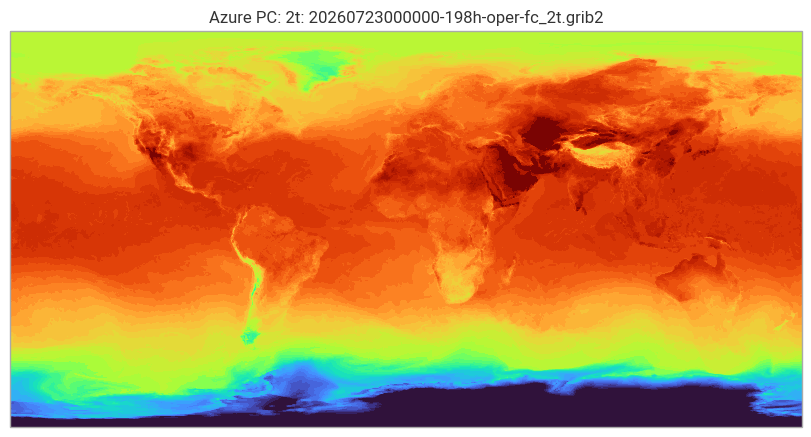

In [7]:
# --- Azure: Single-parameter slice (auto-choose param from the index) ---
# Preference lists
ATMOS_PREF = ["2t", "msl", "tp", "10u", "10v"]
WAVE_PREF  = ["swh", "mwp", "mwd", "pp1d"]

# Load the index and gather available shortNames
idx_text = requests.get(signed_idx, timeout=60).text
shorts = []
for line in idx_text.splitlines():
    try:
        obj = json.loads(line)
        sn  = (obj.get("shortName") or obj.get("param") or "").lower()
        if sn:
            shorts.append(sn)
    except Exception:
        continue

# preserve order, remove dups
seen = {}
shorts = [seen.setdefault(s, s) for s in shorts if s not in seen]
if not shorts:
    raise RuntimeError("Azure: index returned no shortName/param entries.")

# Decide param set by stream
stream_l = str(stream).lower()
pref_list = WAVE_PREF if "wave" in stream_l else ATMOS_PREF
choice = next((p for p in pref_list if p in shorts), shorts[0])  # guaranteed to exist
print("Available shortNames (first 12):", shorts[:12])
print("Picking param:", choice)

# Find offset/length for the chosen param (first match)
offset = length = None
for line in idx_text.splitlines():
    try:
        obj = json.loads(line)
    except Exception:
        continue
    sn = (obj.get("shortName") or obj.get("param") or "").lower()
    if sn == choice:
        offset = int(obj.get("_offset")); length = int(obj.get("_length")); break

if offset is None or length is None:
    raise RuntimeError(f"Param {choice!r} present in list but no offset/length found.")

start, end = offset, offset + length - 1
slice_name = Path(href).name.replace(".grib2", f"_{choice}.grib2")
slice_path = Path(DATA_DIR) / slice_name

print(f"Downloading slice {choice}: bytes {start}-{end} →", slice_path)
with requests.get(
    signed_grib, headers={"Range": f"bytes={start}-{end}"},
    stream=True, timeout=(10, 600)
) as r:
    r.raise_for_status()
    with open(slice_path, "wb") as out:
        for chunk in r.iter_content(256 * 1024):
            if chunk:
                out.write(chunk)

ds = ekd.from_source("file", str(slice_path))
fld = ds[0]
_ = quick_plot(fld, title=f"Azure PC: {choice}: {Path(slice_path).name}")


## 5) Google Cloud Storage: list → pick → preview → slice & plot

**Bucket:** `ecmwf-open-data` (public). We mirror the AWS workflow: list + choose under the chosen date/run, preview with `HEAD`, slice a single parameter using `.index`, and plot.

**Note.** Public GCS URLs use `https://storage.googleapis.com/<bucket>/<key>`. Access example here is anonymous for simplicity, but you can authenticate your activity, read more in the [GSC service documentation](https://cloud.google.com/storage/docs/authentication).


In [8]:
# --- GCS: List & choose a GRIB under the safe date/run ---
gfs = gcsfs.GCSFileSystem(token="anon")
prefix = f"ecmwf-open-data/{fc_date}/{fc_time}z/"
keys = [k for k in gfs.find(prefix) if k.endswith(".grib2")]

def step_from_name(name):
    m = re.search(r"-(\d+)h-", name)
    return int(m.group(1)) if m else 9999

pref = [k for k in keys if "/ifs/" in k and "/0p25/" in k and "/oper/" in k]
pref = sorted(pref, key=lambda k: (step_from_name(k), k)) or sorted(keys)

if not pref:
    raise RuntimeError(f"No .grib2 found under gs://{prefix}. Try re-running later or adjust run.")

key = pref[0]
http_url = f"https://storage.googleapis.com/{key}"
s, lm, _ = _head(http_url)
print("Prefix:", prefix)
print("Chosen key:", key)
print("Preview:", _human(s) if s else "unknown", "| Last-Modified:", lm or "n/a")

Prefix: ecmwf-open-data/20260723/00z/
Chosen key: ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-0h-oper-fc.grib2
Preview: 134.8 MB | Last-Modified: Thu, 23 Jul 2026 07:34:04 GMT


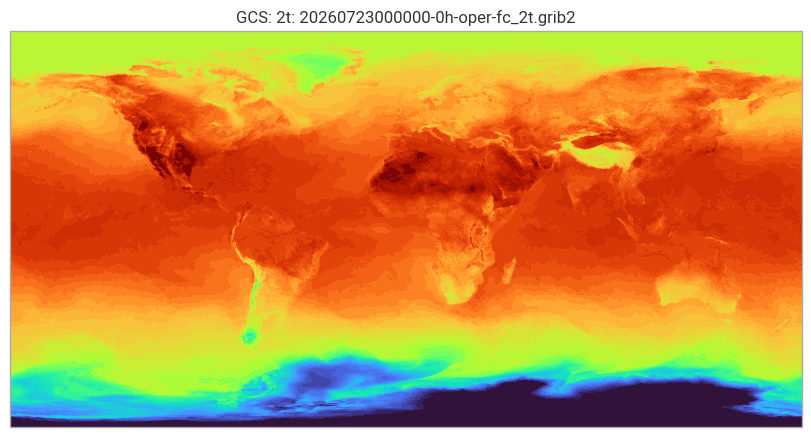

In [9]:
# --- GCS: Single-parameter slice via .index + HTTP Range ---
PARAM_GCS = "2t"  # change as desired; e.g., "msl", "tp"

idx_key = key.replace(".grib2", ".index")
with gfs.open(idx_key, "rb") as f:
    lines = f.read().decode("utf-8","ignore").splitlines()

offset = length = None
for line in lines:
    try:
        obj = json.loads(line)
    except Exception:
        continue
    if (obj.get("param") == PARAM_GCS) or (obj.get("shortName") == PARAM_GCS):
        offset = int(obj.get("_offset")); length = int(obj.get("_length")); break

if offset is None or length is None:
    raise RuntimeError(f"{PARAM_GCS!r} not found in index: gs://{idx_key}")

start, end = offset, offset + length - 1
slice_name = Path(key).name.replace(".grib2", f"_{PARAM_GCS}.grib2")
slice_path = Path(DATA_DIR) / slice_name

print(f"Downloading slice {PARAM_GCS}: bytes {start}-{end} →", slice_path)
with requests.get(http_url, headers={"Range": f"bytes={start}-{end}"}, stream=True, timeout=(10,600)) as r:
    r.raise_for_status()
    with open(slice_path, "wb") as out:
        for chunk in r.iter_content(256*1024):
            if chunk: out.write(chunk)

ds = ekd.from_source("file", str(slice_path))
fld = ds[0]
_ = quick_plot(fld, title=f"GCS: {PARAM_GCS}: {Path(slice_path).name}")

## 6) Quick recipes: `ecmwf-opendata` client (HTTP & AWS)

If you don't want to compose URLs or list buckets yourself, use the **official client** to request files by metadata:

- **`source="ecmwf"`**: retrieve from ECMWF's Open Data HTTP endpoint.
- **`source="aws"`**: retrieve from the AWS mirror.

> Azure links must be **signed**; the plain client can't sign Planetary Computer assets, so you can use the STAC+sign flow above for Azure.


In [10]:
# HTTP (ECMWF): specific steps & params into our shared data cache
from ecmwf.opendata import Client

c = Client(source="aws")
target_http = Path(DATA_DIR) / f"{fc_date}{fc_time}_ifs_oper_2t_msl_t{fc_time}_s0_6_12.grib2"
print("Target:", target_http)

c.retrieve(
    model="ifs",
    stream="oper",
    type="fc",
    levtype="sfc",
    date=fc_date,
    time=int(fc_time),
    step=[0, 6, 12],         # list, or "0/to/12/by/6"
    param="2t/msl",          # slash-separated
    target=str(target_http)
)

print("Saved:", target_http)

Target: /Users/valtze/ecmwf-open-data-guide/data/2026072300_ifs_oper_2t_msl_t00_s0_6_12.grib2


<multiple>:   0%|          | 0.00/3.39M [00:00<?, ?B/s]

By downloading data from the ECMWF open data dataset, you agree to the terms: Attribution 4.0 International (CC BY 4.0). Please attribute ECMWF when downloading this data.
Saved: /Users/valtze/ecmwf-open-data-guide/data/2026072300_ifs_oper_2t_msl_t00_s0_6_12.grib2


In [11]:
# AWS mirror via the client: single step/param example
from ecmwf.opendata import Client

c = Client(source="aws")
target_aws = Path(DATA_DIR) / f"{fc_date}{fc_time}_aws_ifs_oper_2t_t{fc_time}_s0.grib2"
print("Target:", target_aws)

c.retrieve(
    model="ifs",
    stream="oper",
    type="fc",
    levtype="sfc",
    date=fc_date,
    time=int(fc_time),
    step=0,                  # single step
    param="2t",
    target=str(target_aws)
)

print("Saved:", target_aws)

Target: /Users/valtze/ecmwf-open-data-guide/data/2026072300_aws_ifs_oper_2t_t00_s0.grib2


20260723000000-0h-oper-fc.grib2:   0%|          | 0.00/637k [00:00<?, ?B/s]

Saved: /Users/valtze/ecmwf-open-data-guide/data/2026072300_aws_ifs_oper_2t_t00_s0.grib2


## 7) Search files by listing (helpers)

Sometimes you want to **see what exists** before requesting:

- **AWS/GCS**: list keys under the chosen date/run and filter by model/product/step.
- **Azure**: list STAC items and their GRIB assets for your date/run.

We can use follwing helpers to **discover** viable keys/items quickly.


In [12]:
# AWS listing helper: filter and sort by step under the chosen date/run
import s3fs, re
fs = s3fs.S3FileSystem(anon=True, client_kwargs={"region_name":"eu-central-1"})
prefix = f"ecmwf-forecasts/{fc_date}/{fc_time}z/"
keys = [k for k in fs.find(prefix) if k.endswith(".grib2")]
want = [k for k in keys if "/ifs/" in k and "/0p25/" in k and "/oper/" in k]

def step_from_name(n): 
    m = re.search(r"-(\d+)h-", n); 
    return int(m.group(1)) if m else 9999

want = sorted(want, key=step_from_name)
print("Top 10 AWS keys:")
for k in want[:10]:
    print("-", k)

Top 10 AWS keys:
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-0h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-3h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-6h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-9h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-12h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-15h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-18h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-21h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-24h-oper-fc.grib2
- ecmwf-forecasts/20260723/00z/ifs/0p25/oper/20260723000000-27h-oper-fc.grib2


In [13]:
# GCS listing helper: same idea to list relevant files
import gcsfs, re
gfs = gcsfs.GCSFileSystem(token="anon")
prefix = f"ecmwf-open-data/{fc_date}/{fc_time}z/"
keys = [k for k in gfs.find(prefix) if k.endswith(".grib2")]
want = [k for k in keys if "/ifs/" in k and "/0p25/" in k and "/oper/" in k]

def step_from_name(n): 
    m = re.search(r"-(\d+)h-", n); 
    return int(m.group(1)) if m else 9999

want = sorted(want, key=step_from_name)
print("Top 10 GCS keys:")
for k in want[:10]:
    print("-", k)

Top 10 GCS keys:
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-0h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-3h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-6h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-9h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-12h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-15h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-18h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-21h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-24h-oper-fc.grib2
- ecmwf-open-data/20260723/00z/ifs/0p25/oper/20260723000000-27h-oper-fc.grib2


In [14]:
# Azure STAC listing helper: show GRIB asset URLs for our date/run
from pystac_client import Client as STACClient
import planetary_computer as pc

COL_ID = "ecmwf-forecast"
cat = STACClient.open("https://planetarycomputer.microsoft.com/api/stac/v1")
search = cat.search(collections=[COL_ID],
                    sortby=[{"field":"properties.datetime","direction":"desc"}],
                    max_items=40)

yyyy, mm, dd = fc_date[:4], fc_date[4:6], fc_date[6:8]
date_tag = f"{yyyy}-{mm}-{dd}"
time_tag = f"T{fc_time}"

count = 0
print("Azure STAC GRIB assets for selected date/run:")
for item in search.items():
    if (date_tag in item.id) and (time_tag in item.id) and ("wave" not in item.id.lower()):
        gribs = [a.href for a in item.assets.values() if a.href.endswith(".grib2")]
        if gribs:
            print("*", item.id)
            for href in gribs[:5]:
                print("   -", pc.sign(href)[:120] + "...")
            count += 1
    if count >= 5:
        break

Azure STAC GRIB assets for selected date/run:
* ecmwf-2026-07-23T00-waef-ep-360h-0.25
   - https://ai4edataeuwest.blob.core.windows.net/ecmwf/20260723/00z/ifs/0p25/waef/20260723000000-360h-waef-ep.grib2?st=2026-...
* ecmwf-2026-07-23T00-waef-ef-360h-0.25
   - https://ai4edataeuwest.blob.core.windows.net/ecmwf/20260723/00z/ifs/0p25/waef/20260723000000-360h-waef-ef.grib2?st=2026-...
* ecmwf-2026-07-23T00-oper-fc-360h-0.25
   - https://ai4edataeuwest.blob.core.windows.net/ecmwf/20260723/00z/ifs/0p25/oper/20260723000000-360h-oper-fc.grib2?st=2026-...
* ecmwf-2026-07-23T00-enfo-ep-360h-0.25
   - https://ai4edataeuwest.blob.core.windows.net/ecmwf/20260723/00z/ifs/0p25/enfo/20260723000000-360h-enfo-ep.grib2?st=2026-...
* ecmwf-2026-07-23T00-enfo-ef-360h-0.25
   - https://ai4edataeuwest.blob.core.windows.net/ecmwf/20260723/00z/ifs/0p25/enfo/20260723000000-360h-enfo-ef.grib2?st=2026-...


## 8) Wrap‑up

We explored access to ECMWF Open Data from three cloud providers with **tiny downloads** and **quick recipes** using the `ecmwf-opendata` client (HTTP + AWS) as well as **listing helpers** for discovery.

**When full files make sense**
- You truly need **all** parameters/levels for a step, or you're archiving for offline work.
- Expect 50-150 MB for deterministic steps; ensemble data is usually even larger.

**Single‑param slices** is usually the best approach to achieve quick data gathering.

**Next**
- **Notebook 03(Advanced)**: programmatic requests with `ecmwf-opendata` + Earthkit (multi‑params, pressure levels, ensembles, waves).
- **Notebook 03**: blending & comparisons (IFS vs AIFS; with Copernicus CAMS/C3S and EUMETSAT obs).